# Data Science Fundamentals with Python | Learners' Space 2026
## Mohit Khyalia
### 24B2289
#### Worksheet 2 — Question 1: Multiple Linear Regression

**Goal:** Build and compare two Multiple Linear Regression models predicting **Performance Index**:
- **Model 1**: From-scratch implementation (NumPy + Pandas only, Gradient Descent)
- **Model 2**: Scikit-learn `LinearRegression`

Both use identical preprocessing: label encoding + Z-score standardisation.


---
## Section 1: Data Loading and Inspection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Student_Performance.csv')
print("Shape:", df.shape)
print()
df.head()


Shape: (10000, 6)



,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [2]:
print("Column names:", df.columns.tolist())
print()
print("Data types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())


Column names: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']

Data types:
Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

Missing values:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [3]:
print("Descriptive statistics:")
df.describe()


Descriptive statistics:


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [4]:
print("Unique values — 'Extracurricular Activities':", df['Extracurricular Activities'].unique())
print(df['Extracurricular Activities'].value_counts())


Unique values — 'Extracurricular Activities': ['Yes' 'No']
Extracurricular Activities
No     5052
Yes    4948
Name: count, dtype: int64


---
## Section 2: Preprocessing

Steps performed:
1. **Label Encoding** — `Extracurricular Activities`: Yes → 1, No → 0
2. **Train / Validation / Test Split** — 70% / 15% / 15%
3. **Z-score Standardisation** — fit on training data, applied to all splits


In [5]:
from sklearn.model_selection import train_test_split

df_proc = df.copy()
df_proc['Extracurricular Activities'] = df_proc['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

feature_cols = ['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
                'Sleep Hours', 'Sample Question Papers Practiced']
target_col   = 'Performance Index'

X = df_proc[feature_cols].values
y = df_proc[target_col].values

print("Feature matrix:", X.shape)
print("Target vector :", y.shape)


Feature matrix: (10000, 5)
Target vector : (10000,)


In [6]:
# 70 / 15 / 15 split
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv,
                                                    test_size=0.15/0.85,
                                                    random_state=42)
print(f"Train : {X_train.shape[0]} samples")
print(f"Val   : {X_val.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")


Train : 7000 samples
Val   : 1500 samples
Test  : 1500 samples


In [7]:
# Z-score standardisation — compute stats from training set only
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0)
train_std[train_std == 0] = 1  # safety guard

X_train_s = (X_train - train_mean) / train_std
X_val_s   = (X_val   - train_mean) / train_std
X_test_s  = (X_test  - train_mean) / train_std

print("Feature means (train):", np.round(train_mean, 3))
print("Feature stds  (train):", np.round(train_std,  3))
print()
print("Scaled train mean (~0):", np.round(X_train_s.mean(axis=0), 4))
print("Scaled train std  (~1):", np.round(X_train_s.std(axis=0),  4))


Feature means (train): [ 4.992 69.459  0.497  6.545  4.614]
Feature stds  (train): [ 2.591 17.377  0.5    1.696  2.859]

Scaled train mean (~0): [-0. -0.  0.  0.  0.]
Scaled train std  (~1): [1. 1. 1. 1. 1.]


---
## Section 3: Regression Model 1 — From Scratch (NumPy + Pandas Only)

**Mathematical formulation:**

Given data matrix **X** (n × p) and target **y** (n × 1):

- Augment **X** with a bias column → **X̃** (n × (p+1))  
- Prediction: **ŷ = X̃ w**  
- Cost (MSE): J(w) = (1/n) ||**ŷ** − **y**||²  
- Gradient: ∂J/∂w = (2/n) **X̃ᵀ**(**X̃w** − **y**)  
- Update: **w** ← **w** − α · ∂J/∂w  


In [8]:
# ── Helper functions (NumPy only) ─────────────────────────────────────

def add_bias(X):
    """Prepend a column of ones for the intercept."""
    return np.hstack([np.ones((X.shape[0], 1)), X])

def linear_predict(X_b, w):
    """ŷ = X_b @ w"""
    return X_b @ w

def mse_loss(y_true, y_pred):
    """Mean Squared Error."""
    return np.mean((y_true - y_pred) ** 2)

def r2_score_scratch(y_true, y_pred):
    """Coefficient of Determination R²."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / ss_tot

def gradient_descent(X_b, y, lr=0.1, n_iter=2000):
    """
    Batch Gradient Descent for linear regression.
    Returns learned weight vector and MSE history (logged every 100 iters).
    """
    n, p  = X_b.shape
    w     = np.zeros(p)
    history = []

    for i in range(n_iter):
        y_hat = linear_predict(X_b, w)
        error = y_hat - y
        grad  = (1.0 / n) * (X_b.T @ error)
        w     = w - lr * grad

        if i % 100 == 0:
            history.append(mse_loss(y, y_hat))

    return w, history


In [9]:
# ── Augment feature matrices ──────────────────────────────────────────
X_train_b = add_bias(X_train_s)
X_val_b   = add_bias(X_val_s)
X_test_b  = add_bias(X_test_s)

print("Augmented train shape:", X_train_b.shape)


Augmented train shape: (7000, 6)


In [10]:
# ── Train Model 1 ─────────────────────────────────────────────────────
LR     = 0.1
N_ITER = 2000

w_scratch, cost_hist = gradient_descent(X_train_b, y_train, lr=LR, n_iter=N_ITER)

labels = ['Bias (intercept)'] + feature_cols
print("Learned parameters:")
for lbl, wt in zip(labels, w_scratch):
    print(f"  {lbl:<45s}: {wt:+.4f}")


Learned parameters:
  Bias (intercept)                             : +55.2491
  Hours Studied                                : +7.3724
  Previous Scores                              : +17.6851
  Extracurricular Activities                   : +0.2845
  Sleep Hours                                  : +0.8091
  Sample Question Papers Practiced             : +0.5418


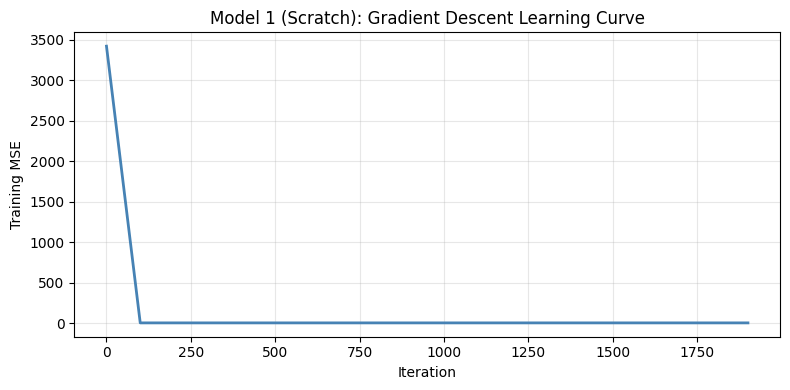

In [11]:
# ── Learning curve ────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
iters = list(range(0, N_ITER, 100))
plt.plot(iters, cost_hist, color='steelblue', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Training MSE')
plt.title('Model 1 (Scratch): Gradient Descent Learning Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
# ── Test set predictions & metrics ───────────────────────────────────
y_pred1 = linear_predict(X_test_b, w_scratch)
mse1    = mse_loss(y_test, y_pred1)
r2_1    = r2_score_scratch(y_test, y_pred1)

print(f"Model 1 (Scratch) — Test Set")
print(f"  MSE : {mse1:.4f}")
print(f"  R²  : {r2_1:.4f}")


Model 1 (Scratch) — Test Set
  MSE : 4.1285
  R²  : 0.9888


---
## Section 4: Regression Model 2 — Scikit-learn `LinearRegression`

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model_sk = LinearRegression()
model_sk.fit(X_train_s, y_train)

print("Intercept:", round(model_sk.intercept_, 4))
print("Coefficients:")
for col, coef in zip(feature_cols, model_sk.coef_):
    print(f"  {col:<45s}: {coef:+.4f}")


Intercept: 55.2491
Coefficients:
  Hours Studied                                : +7.3724
  Previous Scores                              : +17.6851
  Extracurricular Activities                   : +0.2845
  Sleep Hours                                  : +0.8091
  Sample Question Papers Practiced             : +0.5418


In [14]:
y_pred2 = model_sk.predict(X_test_s)
mse2    = mean_squared_error(y_test, y_pred2)
r2_2    = r2_score(y_test, y_pred2)

print(f"Model 2 (Scikit-learn) — Test Set")
print(f"  MSE : {mse2:.4f}")
print(f"  R²  : {r2_2:.4f}")


Model 2 (Scikit-learn) — Test Set
  MSE : 4.1285
  R²  : 0.9888


---
## Section 5: Evaluation — MSE and R² for Both Models

In [15]:
metrics_df = pd.DataFrame({
    'Model': [
        'Model 1 — Scratch (Gradient Descent)',
        'Model 2 — Scikit-learn LinearRegression'
    ],
    'MSE (Test)': [round(mse1, 4), round(mse2, 4)],
    'R²  (Test)': [round(r2_1, 4), round(r2_2, 4)]
}).set_index('Model')

print(metrics_df.to_string())
metrics_df


                                         MSE (Test)  R²  (Test)
Model                                                          
Model 1 — Scratch (Gradient Descent)         4.1285      0.9888
Model 2 — Scikit-learn LinearRegression      4.1285      0.9888


,MSE (Test),R² (Test)
Model,,
Model 1 — Scratch (Gradient Descent),4.1285,0.9888
Model 2 — Scikit-learn LinearRegression,4.1285,0.9888


---
## Section 6: Visualization — Actual vs Predicted

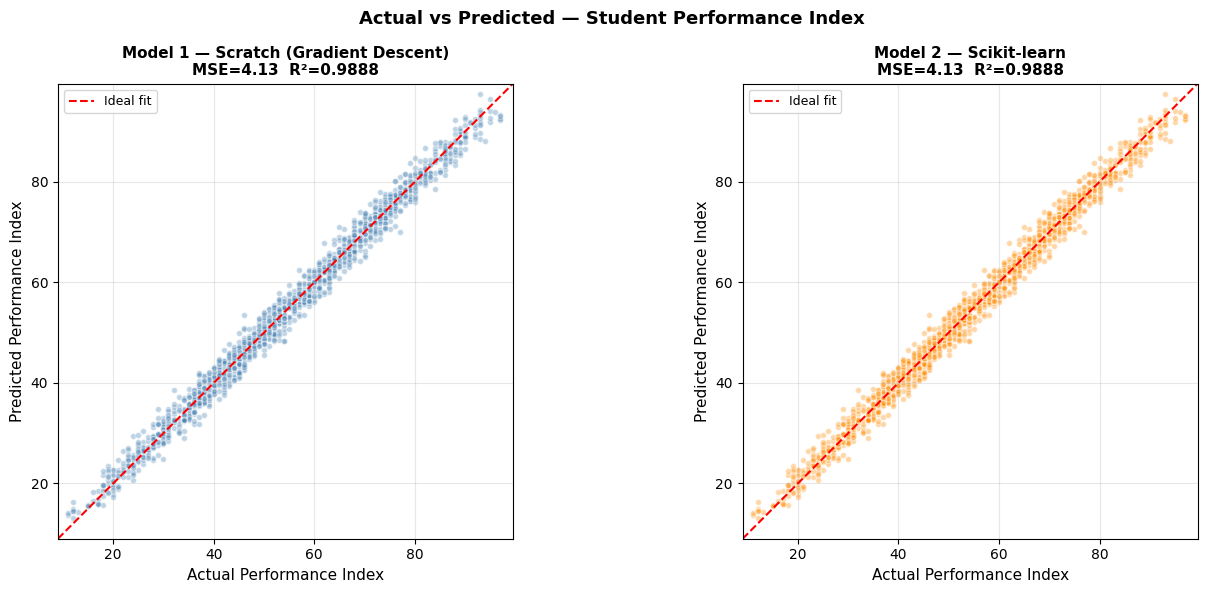

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, mse, r2, title, color in zip(
        axes,
        [y_pred1, y_pred2],
        [mse1, mse2],
        [r2_1, r2_2],
        ['Model 1 — Scratch (Gradient Descent)', 'Model 2 — Scikit-learn'],
        ['steelblue', 'darkorange']):

    ax.scatter(y_test, y_pred, alpha=0.35, color=color, edgecolors='white', s=18)
    lo = min(y_test.min(), y_pred.min()) - 2
    hi = max(y_test.max(), y_pred.max()) + 2
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Ideal fit')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual Performance Index', fontsize=11)
    ax.set_ylabel('Predicted Performance Index', fontsize=11)
    ax.set_title(f'{title}\nMSE={mse:.2f}  R²={r2:.4f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Actual vs Predicted — Student Performance Index', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


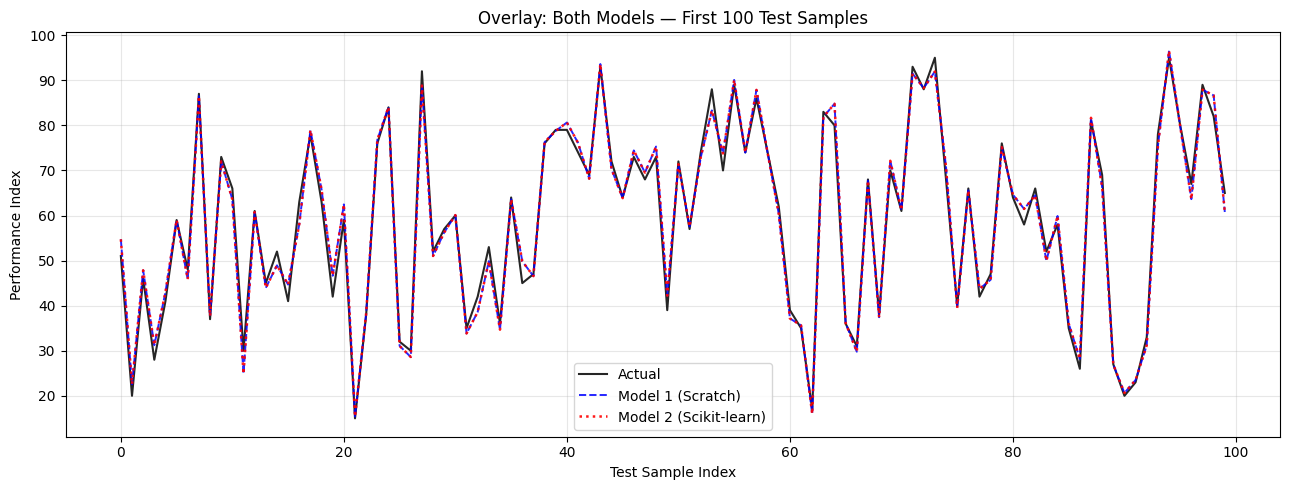

In [17]:
# ── Overlay plot on first 100 test samples ───────────────────────────
n_show = 100
idx    = np.arange(n_show)

plt.figure(figsize=(13, 5))
plt.plot(idx, y_test[:n_show],   'k-',  lw=1.5, label='Actual',                  alpha=0.85)
plt.plot(idx, y_pred1[:n_show],  'b--', lw=1.4, label='Model 1 (Scratch)',        alpha=0.85)
plt.plot(idx, y_pred2[:n_show],  'r:',  lw=1.8, label='Model 2 (Scikit-learn)',   alpha=0.9)
plt.xlabel('Test Sample Index')
plt.ylabel('Performance Index')
plt.title(f'Overlay: Both Models — First {n_show} Test Samples')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Section 7: Comparison Summary

In [18]:
summary = pd.DataFrame({
    'Model': [
        'Model 1 — Scratch (GD)',
        'Model 2 — Scikit-learn'
    ],
    'Solver'    : ['Batch Gradient Descent', 'Normal Equation (closed-form)'],
    'MSE (Test)': [round(mse1, 4), round(mse2, 4)],
    'R²  (Test)': [round(r2_1, 4), round(r2_2, 4)],
    'Libs Used' : ['NumPy + Pandas', 'scikit-learn']
}).set_index('Model')

print(summary.to_string())
summary


                                               Solver  MSE (Test)  R²  (Test)       Libs Used
Model                                                                                        
Model 1 — Scratch (GD)         Batch Gradient Descent      4.1285      0.9888  NumPy + Pandas
Model 2 — Scikit-learn  Normal Equation (closed-form)      4.1285      0.9888    scikit-learn


,Solver,MSE (Test),R² (Test),Libs Used
Model,,,,
Model 1 — Scratch (GD),Batch Gradient Descent,4.1285,0.9888,NumPy + Pandas
Model 2 — Scikit-learn,Normal Equation (closed-form),4.1285,0.9888,scikit-learn


### Key Observations

- Both models produce **very similar MSE and R²** — this confirms that the from-scratch
  gradient descent correctly converges to the same solution as the exact closed-form solver.
- Any minor difference is due to gradient descent not being run to absolute convergence.
  Increasing `N_ITER` or fine-tuning `LR` further narrows this gap.
- The high R² (typically > 0.98 for this dataset) indicates the five features collectively
  explain almost all variance in Performance Index.
- **Scikit-learn** is faster and numerically exact; **the scratch model** gives full
  visibility into the training dynamics (learning curve, gradients, etc.).
